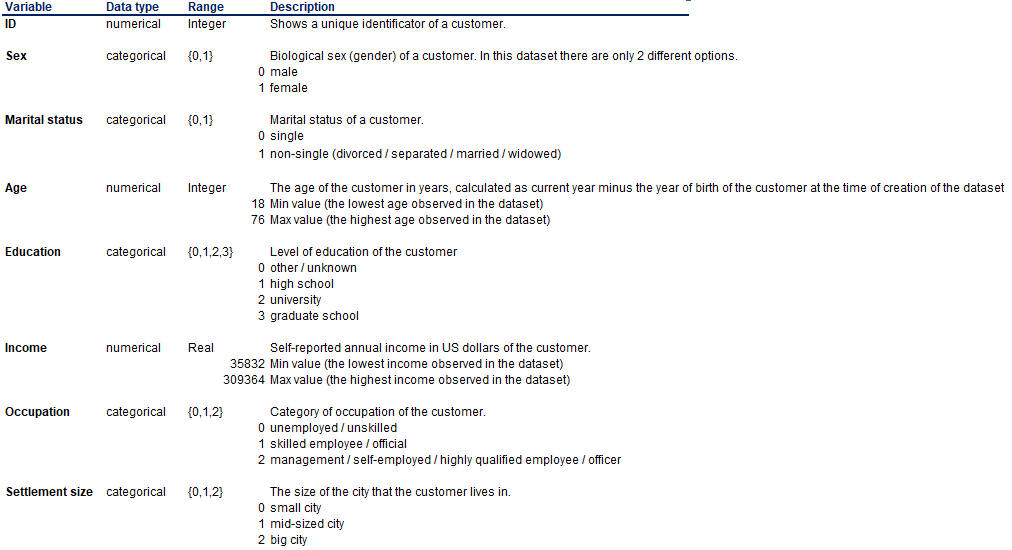

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [3]:
data_path = "data/customer-clustering/segmentation data.csv"

## Spark

In [ ]:
spark = (
    SparkSession.builder
    .appName("test")
    .getOrCreate()
)
print(spark.sparkContext.uiWebUrl)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/02/08 14:19:55 WARN Utils: Your hostname, void, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/02/08 14:19:55 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/08 14:19:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


http://10.255.255.254:4040


In [6]:
df_spark = spark.read.csv(data_path, header=True)

In [8]:
df_spark.show(5, True, True)

-RECORD 0--------------------
 ID              | 100000001 
 Sex             | 0         
 Marital status  | 0         
 Age             | 67        
 Education       | 2         
 Income          | 124670    
 Occupation      | 1         
 Settlement size | 2         
-RECORD 1--------------------
 ID              | 100000002 
 Sex             | 1         
 Marital status  | 1         
 Age             | 22        
 Education       | 1         
 Income          | 150773    
 Occupation      | 1         
 Settlement size | 2         
-RECORD 2--------------------
 ID              | 100000003 
 Sex             | 0         
 Marital status  | 0         
 Age             | 49        
 Education       | 1         
 Income          | 89210     
 Occupation      | 0         
 Settlement size | 0         
-RECORD 3--------------------
 ID              | 100000004 
 Sex             | 0         
 Marital status  | 0         
 Age             | 45        
 Education       | 1         
 Income   

In [10]:
df_spark.printSchema()
df_spark.columns

root
 |-- ID: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Marital status: string (nullable = true)
 |-- Age: string (nullable = true)
 |-- Education: string (nullable = true)
 |-- Income: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- Settlement size: string (nullable = true)



['ID',
 'Sex',
 'Marital status',
 'Age',
 'Education',
 'Income',
 'Occupation',
 'Settlement size']

In [11]:
df_spark.show(5)

+---------+---+--------------+---+---------+------+----------+---------------+
|       ID|Sex|Marital status|Age|Education|Income|Occupation|Settlement size|
+---------+---+--------------+---+---------+------+----------+---------------+
|100000001|  0|             0| 67|        2|124670|         1|              2|
|100000002|  1|             1| 22|        1|150773|         1|              2|
|100000003|  0|             0| 49|        1| 89210|         0|              0|
|100000004|  0|             0| 45|        1|171565|         1|              1|
|100000005|  0|             0| 53|        1|149031|         1|              1|
+---------+---+--------------+---+---------+------+----------+---------------+
only showing top 5 rows


### Select

In [13]:
(
    df_spark
    .select("Sex")
    .distinct()
    .show(10)
)

+---+
|Sex|
+---+
|  0|
|  1|
+---+



### GroupBy

In [ ]:
(
    df_spark
    .groupBy("Sex")
    .agg(F.count("*").alias("total_rows"))
).show()

+---+----------+
|Sex|total_rows|
+---+----------+
|  0|      1086|
|  1|       914|
+---+----------+



In [16]:
(
    df_spark
    .groupBy("Sex")
    .agg(F.mean("Age").alias("average_age"))
).show()

+---+------------------+
|Sex|       average_age|
+---+------------------+
|  0|37.874769797421735|
|  1| 33.57330415754923|
+---+------------------+



In [ ]:
(
    df_spark
    .groupBy("Marital status")
    .agg(F.mean("Age").alias("average_age"))
).show()

+--------------+------------------+
|Marital status|       average_age|
+--------------+------------------+
|             0| 38.38927507447865|
|             1|33.393756294058406|
+--------------+------------------+



In [32]:
(
    df_spark
    .groupBy("Settlement size")
    .agg(F.round(F.mean("Income"), 2).alias("average_income"))
    .orderBy("average_income", ascending=False)
).show()

+---------------+--------------+
|Settlement size|average_income|
+---------------+--------------+
|              2|     143889.99|
|              1|     137430.34|
|              0|     101061.79|
+---------------+--------------+



### Filtering

In [ ]:
df_married_female = (df_spark
                     .where((F.col("Sex") == 1) & (F.col("Marital status") == 1))
                     )

df_married_female = df_married_female.withColumnRenamed("Marital status", "Is_married")

(
    df_married_female
    .groupBy("Settlement size")
    .agg(F.round(F.mean("Income"), 2).alias("average_income"))
    .orderBy("average_income", ascending=False)
).show()

+---------------+--------------+
|Settlement size|average_income|
+---------------+--------------+
|              2|     144044.27|
|              1|     131247.47|
|              0|     102543.42|
+---------------+--------------+



Тоже самое но в pandas

In [58]:
data_married_female = data[(data["Sex"] == 1) & (data["Marital status"] == 1)]

(
    data_married_female
    .groupby("Settlement size")
    .agg(average_income=("Income", "mean"))
    .round(2)
    .sort_values("average_income", ascending=False)
)

,average_income
Settlement size,
2,144044.27
1,131247.47
0,102543.42


### Save to CSV

In [ ]:
# Неконтролируемое по кол-ву файлов

# сохраняет то кол-во csv файлов, чему равно кол-во партиций

(
    df_married_female
    .write
    .format("csv")
    .options(header=True)
    .csv("data/artifacts/married_female_no_control")
)

num_partition = df_married_female.rdd.getNumPartitions()
print(f"Кол-во патиций: {num_partition}")


Кол-во патиций: 1


In [ ]:
# Сохраняет контролируемое по кол-ву файлов - ОДИН ФАЙЛ

(
    df_married_female
    .coalesce(1) # !
    .write
    .format("csv")
    .options(header=True, sep=";")
    .csv("data/artifacts/married_female_one_file")
)

In [ ]:
# Сохранение с партиционированием

# то есть разбиваем датасет по столбцу и 
# сохраняем то кол-во файлов чему равно кол-во уникальных значений в столбце
# и сохраняет то кол-во csv файлов, чему равно кол-во партиций

(
    df_spark
    .write
    .partitionBy("Sex") # !
    .format("csv")
    .options(header=True)
    .csv("data/artifacts/partitioned_by_sex")
)

In [96]:
# Сохранение с партиционированием и repartition

(
    df_spark
    .repartition(1, "Sex")
    .write
    .partitionBy("Sex")
    .format("csv")
    .options(header=True)
    .csv("data/artifacts/partitioned_by_sex_and_repart")
)

### Read Transformed

# Data Mining

In [4]:
data = pd.read_csv("data/customer-clustering/segmentation data.csv")

In [ ]:
data.head(10)
display(data.describe())
data.info()
print(f"\nNUll:\n{data.isna().sum()}")
print(f"\nDuplicates: {data.duplicated().sum()}")

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1.000010e+08,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,5.774946e+02,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,1.000000e+08,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,1.000005e+08,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,1.000010e+08,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000015e+08,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000020e+08,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB

NUll:
ID                 0
Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64

Dublicates: 0


In [7]:
data.skew()

ID                 0.000000
Sex                0.172769
Marital status     0.014011
Age                1.009940
Education          0.487172
Income             1.196085
Occupation         0.188522
Settlement size    0.510541
dtype: float64

In [72]:
eda_data = data.copy()

eda_data["Sex"] = eda_data["Sex"].replace({0: "Male", 1: "Female"})
eda_data["Marital status"] = eda_data["Marital status"].replace({0: "Single", 1: "No single"})
eda_data["Education"] = eda_data["Education"].replace({0: "Other", 1: "High school", 2: "Univ.", 3: "Graduate school"})
eda_data["Occupation"] = eda_data["Occupation"].replace({0: "unemployed", 1: "skilled employee", 2: "highly qualified"})
eda_data["Settlement size"] = eda_data["Settlement size"].replace({0: "small city", 1: "mid-sized city", 2: "big city"})

eda_data.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,Male,Single,67,Univ.,124670,skilled employee,big city
1,100000002,Female,No single,22,High school,150773,skilled employee,big city
2,100000003,Male,Single,49,High school,89210,unemployed,small city
3,100000004,Male,Single,45,High school,171565,skilled employee,mid-sized city
4,100000005,Male,Single,53,High school,149031,skilled employee,mid-sized city


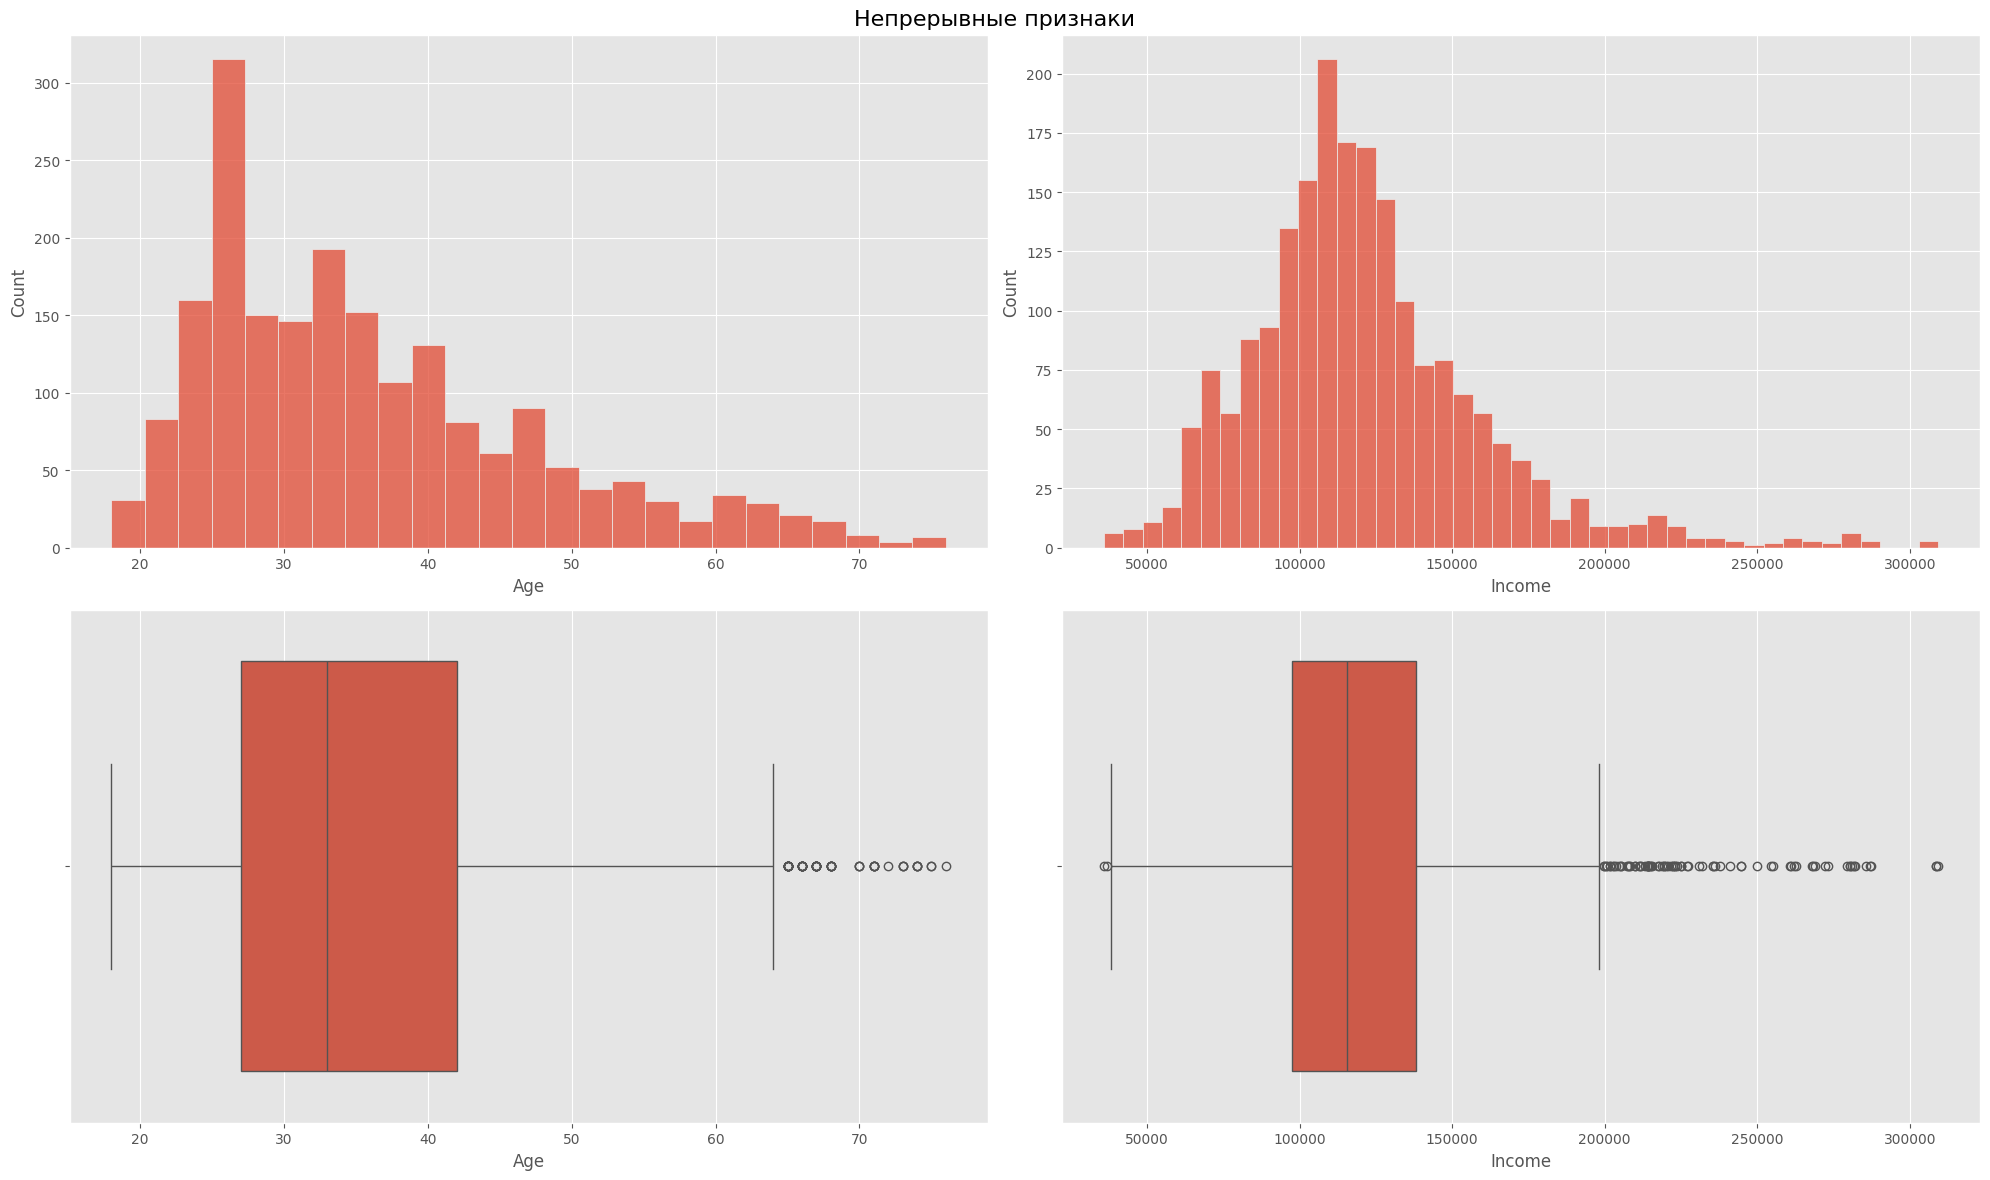

In [122]:
num_cols = data.loc[:, data.columns != "ID"].select_dtypes(["int64"]).columns
cont_cols = ["Age", "Income"]
disc_col = ["Sex", "Marital status", "Education", "Occupation", "Settlement size"]

fig, ax = plt.subplots(2, 2, figsize=(20, 12))

for i, col in enumerate(cont_cols):
    sns.histplot(x=eda_data[col], ax=ax[0, i])
    sns.boxplot(x=eda_data[col], ax=ax[1, i])

fig.suptitle("Непрерывные признаки", fontsize=16)
plt.tight_layout()
plt.show()


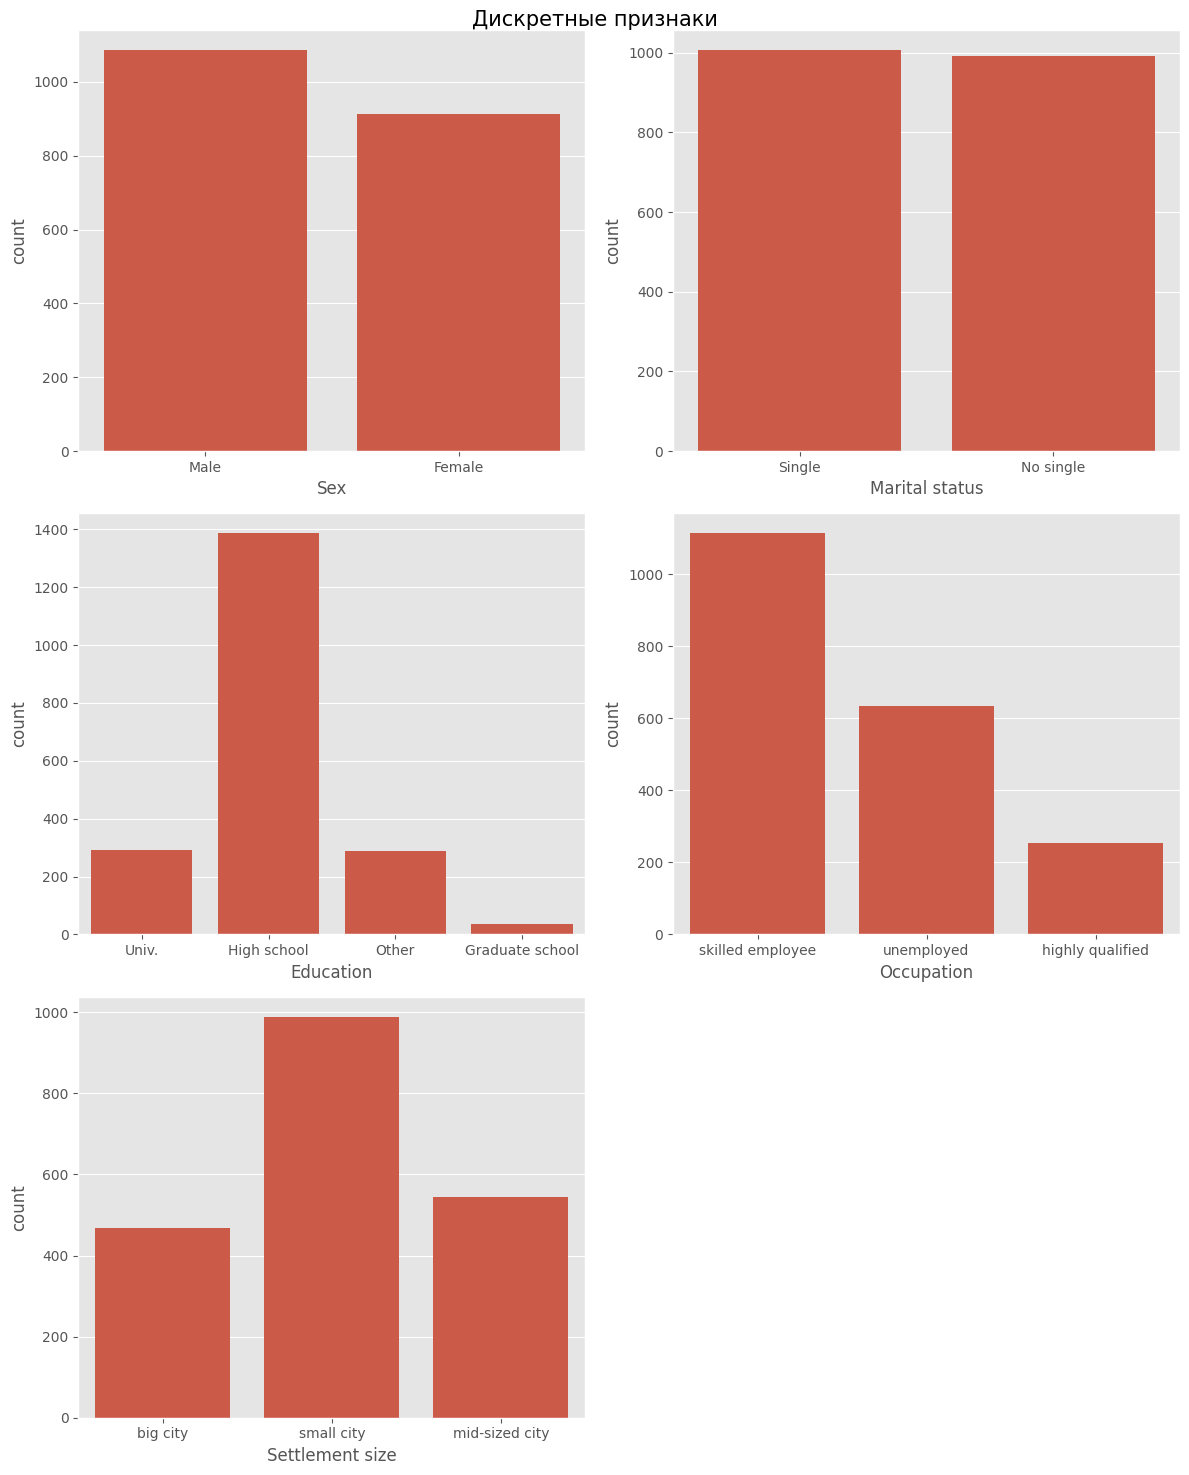

In [123]:
fig, ax = plt.subplots(3, 2, figsize=(12, 15))
ax = ax.flatten()

for i, col in enumerate(disc_col):
    sns.countplot(x=eda_data[col], ax=ax[i])

ax[-1].set_visible(False)
fig.suptitle("Дискретные признаки", fontsize=15)
plt.tight_layout()
plt.show()


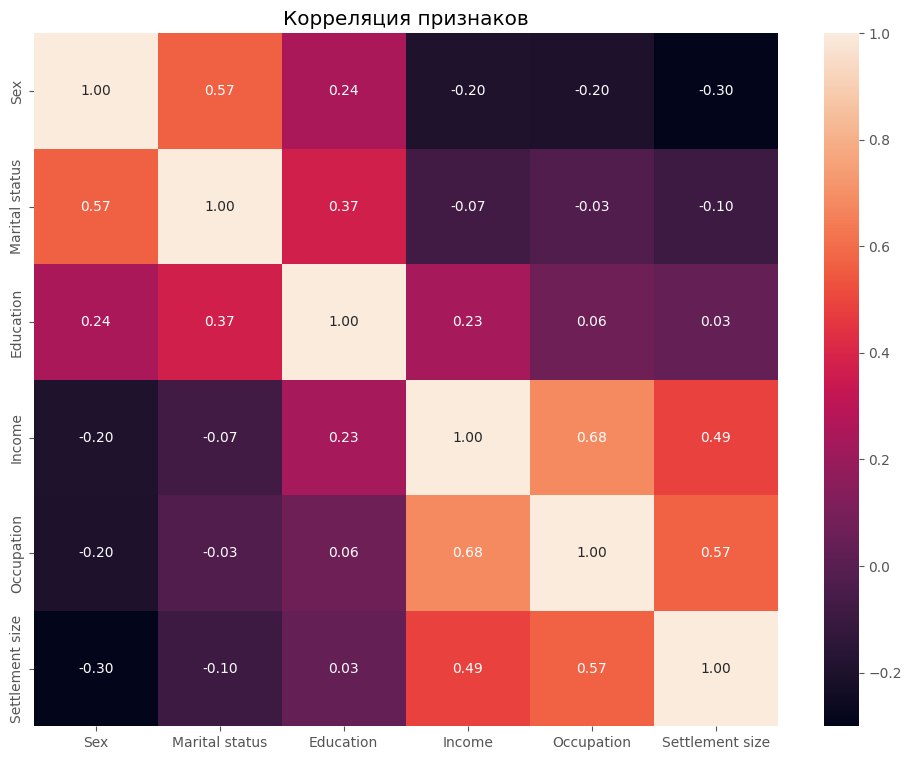

In [124]:
corr_mtrx = data[num_cols].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr_mtrx, annot=True, fmt=".2f")
plt.title("Корреляция признаков")
plt.show()

Корреляция которые нужно проверить:
1. Sex -> Marital status = 0.57
2. Age -> Education = 0.65
3. Income -> Occupation = 0.68
4. Income -> Settlement size = 0.49
6. Occupation -> Settlement size = 0.57

In [88]:
print(cont_cols, disc_col, sep="\n")

['Age', 'Income']
['Sex', 'Marital status', 'Education', 'Occupation', 'Settlement size']


<Axes: xlabel='Education', ylabel='Age'>

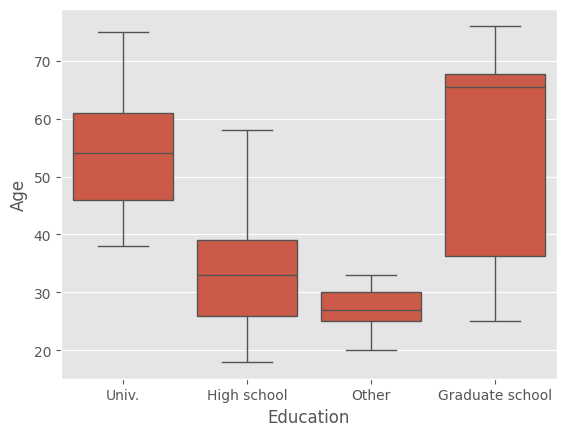

In [125]:
sns.boxplot(x=eda_data["Education"], y=eda_data["Age"])

In [93]:
pd.crosstab(eda_data["Sex"], eda_data["Marital status"], normalize="index")

Marital status,No single,Single
Sex,,
Female,0.805252,0.194748
Male,0.236648,0.763352


In [ ]:
pd.pivot_table

In [116]:
data.loc[data["Age"] > 30, "Age"] = np.nan
data

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,NaN,2,124670,1,2
1,100000002,1,1,NaN,1,150773,1,2
2,100000003,0,0,NaN,1,89210,0,0
3,100000004,0,0,NaN,1,171565,1,1
4,100000005,0,0,NaN,1,149031,1,1
...,...,...,...,...,...,...,...,...
1995,100001996,1,0,NaN,1,123525,0,0
1996,100001997,1,1,NaN,1,117744,1,0
1997,100001998,0,0,NaN,0,86400,0,0
1998,100001999,1,1,NaN,1,97968,0,0


In [117]:
data["Age"] = data["Age"].fillna(data["Age"].median())

data.isna().sum()

ID                 0
Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64

In [ ]:
data[]["Age"] = None
data

/tmp/ipykernel_20953/816440330.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[data["Age"] < 30]["Age"] = None


,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1
...,...,...,...,...,...,...,...,...
1995,100001996,1,0,47,1,123525,0,0
1996,100001997,1,1,27,1,117744,1,0
1997,100001998,0,0,31,0,86400,0,0
1998,100001999,1,1,24,1,97968,0,0
